<a href="https://colab.research.google.com/github/Serragem/ModelagemVQE/blob/main/TesteHeH(qc).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

##FUNÇÃO DO VALOR ESPERADO

In [ ]:

def E(params, estado_qc, observavel_op, aer_flag, backend=None, shots=None):
    qc = estado_qc.copy()
    dic_parametros = {estado_qc.parameters[k]: params[k] for k in range(len(params))}
    qc = qc.assign_parameters(dic_parametros)

    if shots is None:
        shots = 2**10

    if aer_flag is True:
        aer_simulator = AerSimulator()
        pm = generate_preset_pass_manager(backend=aer_simulator, optimization_level=1)
        isa_qc = pm.run(qc)
        isa_observavel = observavel_op.apply_layout(isa_qc.layout)

        with Session(backend=aer_simulator) as session:
            estimator = Estimator(mode=session)
            estimator.options.default_shots = shots
            job = estimator.run([(isa_qc, isa_observavel)])
            pub_result = job.result()[0]
            expval = pub_result.data.evs
    else:
        expval = None

    return expval


##PARAMETRIZAÇÃO DO CIRCUITO

Circuito de preparação do estado inicial:


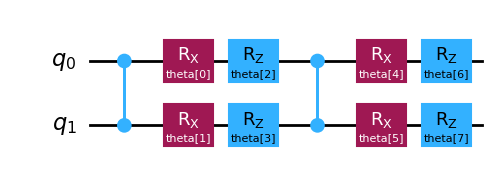

In [ ]:
qr = QuantumRegister(2, 'q')
qc_estado = QuantumCircuit(qr)
theta = ParameterVector('theta', 8)

for k in range(8):
    if k % 4 == 0:
        qc_estado.cz(qr[0], qr[1])
        qc_estado.rx(theta[k], qr[0])
    elif k % 4 == 1:
        qc_estado.rx(theta[k], qr[1])
    elif k % 4 == 2:
        qc_estado.rz(theta[k], qr[0])
    elif k % 4 == 3:
        qc_estado.rz(theta[k], qr[1])

print("Circuito de preparação do estado inicial:")
display(qc_estado.draw('mpl'))

##DEFINIÇÃO DO HAMILTONIANO

In [ ]:
opers = ['II', 'XI', 'IX', 'ZI', 'IZ', 'XX', 'ZZ', 'XZ', 'ZX']

C = -4.1224
Jx = -0.2392
Jz = -0.9716
Jxx = 0.1610
Jxz = 0.2392
Jzz = 0.3902


coefs = [C, Jx, Jx, Jz, Jz, Jxx, Jzz, Jxz, Jxz]
H = SparsePauliOp(opers, coefs)

print("Hamiltoniano:")
display(H)

Hamiltoniano:


SparsePauliOp(['II', 'XI', 'IX', 'ZI', 'IZ', 'XX', 'ZZ', 'XZ', 'ZX'],
              coeffs=[-4.1224+0.j, -0.2392+0.j, -0.2392+0.j, -0.9716+0.j, -0.9716+0.j,
  0.161 +0.j,  0.3902+0.j,  0.2392+0.j,  0.2392+0.j])

##OTIMIZAÇÃO VIA METHOD: COBYLA

In [ ]:
params_val = [0.0 for _ in range(8)]

print(f"Parâmetros de preparação do estado quântico inicial do VQE:")
print(params_val)

H_val = H.copy()
qc_estado_val = qc_estado.copy()
aer_val = True
backend_val = None
shots = 2**12

resultado = minimize(
    E,
    params_val,
    args=(qc_estado_val, H_val, aer_val, backend_val, shots),
    tol=1/2**12,
    method="COBYLA"
)

print("Resultado da otimização:")
print(resultado)

Parâmetros de preparação do estado quântico inicial do VQE:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Resultado da otimização:
 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -5.6964398437499995
       x: [ 5.258e-04  6.373e-04  1.002e+00 -1.245e-03  3.939e-02
           -4.651e-02 -5.619e-03 -4.703e-02]
    nfev: 65
   maxcv: 0.0


## ESTADO FUNDAMENTAL

Estado fundamental:


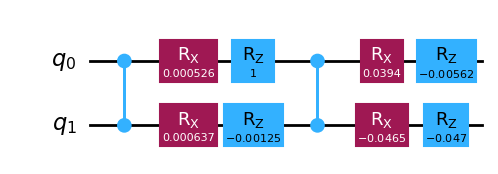

<IPython.core.display.Latex object>

Energia fundamental:
-5.6964398437499995


In [ ]:
print("Estado fundamental:")

dict_parametros = {theta[k]: resultado.x[k] for k in range(8)}
qc_estado_opt = qc_estado.copy().assign_parameters(dict_parametros)
display(qc_estado_opt.draw('mpl'))

vetorestado = Statevector.from_instruction(qc_estado_opt)
display(vetorestado.draw('latex'))

print("Energia fundamental:")
print(resultado.fun)